In [4]:
# setup and load clean data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('titanic_clean.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Shape: (784, 9)

Columns: ['survived', 'class', 'sex', 'age', 'siblings_spouses', 'parents_children', 'fare', 'embarked', 'is_alone']

First few rows:
   survived  class     sex   age  siblings_spouses  parents_children     fare  \
0         0      3    male  22.0                 1                 0   7.2500   
1         1      1  female  38.0                 1                 0  71.2833   
2         1      3  female  26.0                 0                 0   7.9250   
3         1      1  female  35.0                 1                 0  53.1000   
4         0      3    male  35.0                 0                 0   8.0500   

  embarked  is_alone  
0        S     False  
1        C     False  
2        S      True  
3        S     False  
4        S      True  


In [12]:
# Exploratory Questions 1-8
# Q1: What was the overall survival rate?
survival_rate = df['survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

Overall survival rate: 41.2%


In [8]:
# Q2: Did passenger class affect survival?
survival_by_class = df.groupby('class')['survived'].mean() * 100
print("\nSurvival rate by class:")
print(survival_by_class)


Survival rate by class:
class
1    63.084112
2    50.909091
3    25.679012
Name: survived, dtype: float64


In [9]:
# Q3: Did gender affect survival?
survival_by_sex = df.groupby('sex')['survived'].mean() * 100
print("\nSurvival rate by gender:")
print(survival_by_sex)


Survival rate by gender:
sex
female    74.061433
male      21.588595
Name: survived, dtype: float64


In [13]:
# Q4: What was the age distribution of survivors vs non-survivors?
print("\nAge statistics by survival:")
print(df.groupby('survived')['age'].describe())


Age statistics by survival:
          count       mean        std   min   25%   50%   75%   max
survived                                                           
0         461.0  30.387202  13.661684  1.00  22.0  28.0  37.0  74.0
1         323.0  28.464149  14.183749  0.42  20.5  28.0  37.0  80.0


In [14]:
# Q5: Did having family aboard affect survival?
survival_by_alone = df.groupby('is_alone')['survived'].mean() * 100
print("\nSurvival rate (alone vs with family):")
print(survival_by_alone)


Survival rate (alone vs with family):
is_alone
False    51.183432
True     33.632287
Name: survived, dtype: float64


In [15]:
# Q6: Which embarkation port had highest survival rate?
survival_by_port = df.groupby('embarked')['survived'].mean() * 100
print("\nSurvival rate by embarkation port:")
print(survival_by_port)


Survival rate by embarkation port:
embarked
C    58.064516
Q    33.898305
S    37.368421
Name: survived, dtype: float64


In [16]:
# Q7: What was the relationship between fare paid and survival?
print("\nFare statistics by survival:")
print(df.groupby('survived')['fare'].describe())


Fare statistics by survival:
          count       mean        std  min     25%    50%       75%       max
survived                                                                     
0         461.0  23.944531  33.336385  0.0   7.875  13.00  26.55000  263.0000
1         323.0  50.079180  68.009971  0.0  12.825  26.25  61.37915  512.3292


In [17]:
# Q8: Did age affect survival differently by class?
survival_age_class = df.groupby(['class', pd.cut(df['age'], bins=[0, 18, 60, 100])])['survived'].mean()
print("\nSurvival by class and age group:")
print(survival_age_class)


Survival by class and age group:
class  age      
1      (0, 18]      0.875000
       (18, 60]     0.641304
       (60, 100]    0.214286
2      (0, 18]      0.821429
       (18, 60]     0.447761
       (60, 100]    0.333333
3      (0, 18]      0.351648
       (18, 60]     0.229773
       (60, 100]    0.200000
Name: survived, dtype: float64


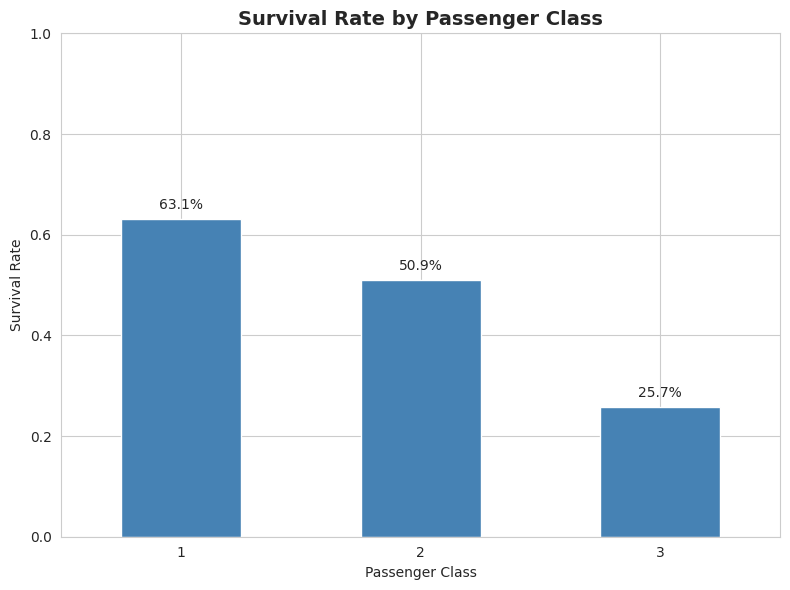

In [20]:
# Bar chart: Survival by passenger class
survival_by_class = df.groupby('class')['survived'].mean()

plt.figure(figsize=(8, 6))
survival_by_class.plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)

# Add percentage labels on bars
for i, v in enumerate(survival_by_class):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('survival_by_class.png')
plt.show()

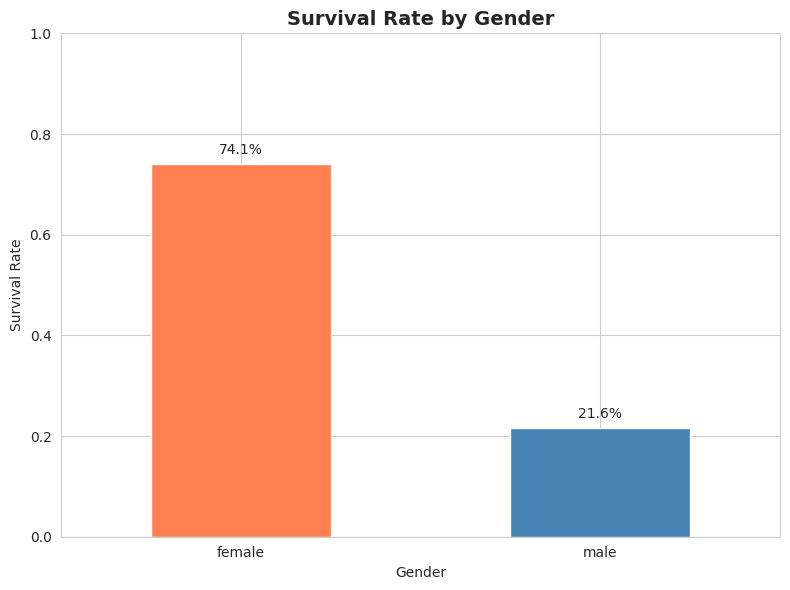

In [21]:
# Bar chart: Survival by gender

survival_by_sex = df.groupby('sex')['survived'].mean()

plt.figure(figsize=(8, 6))
survival_by_sex.plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Survival Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)

for i, v in enumerate(survival_by_sex):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('survival_by_sex.png')
plt.show()

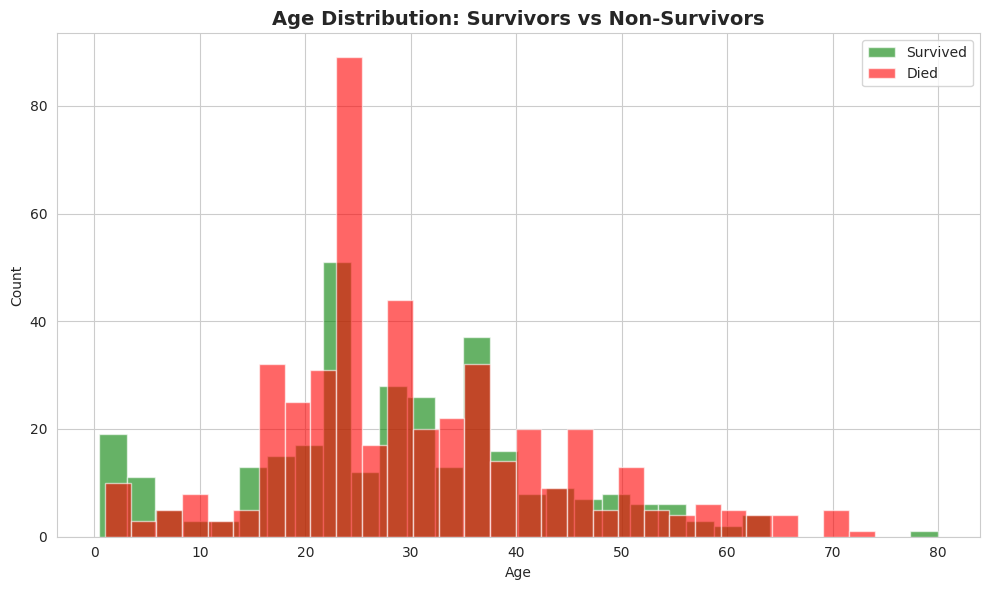

In [22]:
# Histogram: Age distribution survivors vs non-survivors

plt.figure(figsize=(10, 6))

# Histogram for both groups
df[df['survived'] == 1]['age'].hist(bins=30, alpha=0.6, label='Survived', color='green')
df[df['survived'] == 0]['age'].hist(bins=30, alpha=0.6, label='Died', color='red')

plt.title('Age Distribution: Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

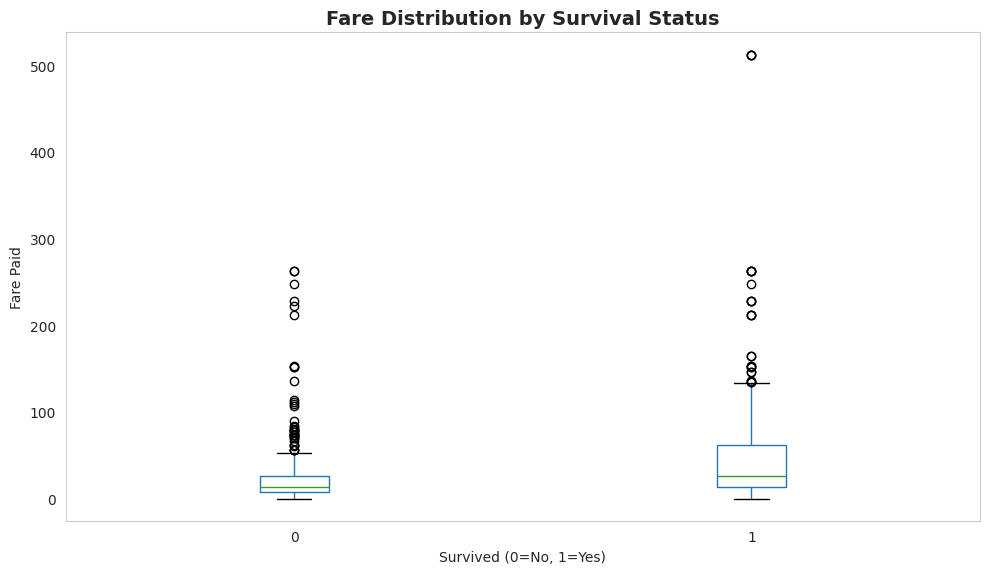

In [23]:
# Boxplot: fare vs survival
plt.figure(figsize=(10, 6))

df.boxplot(column='fare', by='survived', grid=False)
plt.title('Fare Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove auto title
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare Paid')
plt.tight_layout()
plt.savefig('fare_vs_survival.png')
plt.show()

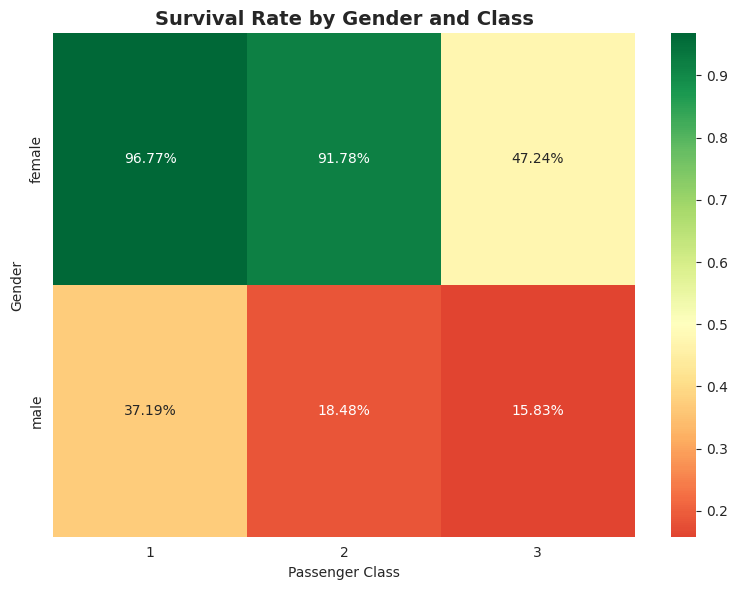

In [24]:
# Heatmap - Survival by Class and Gender
survival_pivot = df.pivot_table(
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, fmt='.2%', cmap='RdYlGn', center=0.5)
plt.title('Survival Rate by Gender and Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Gender')
plt.tight_layout()
plt.savefig('survival_heatmap.png')
plt.show()

In [27]:
# Create a summary dataframe
summary = pd.DataFrame({
    'Factor': ['Overall', 'First Class', 'Second Class', 'Third Class', 
               'Women', 'Men', 'With Family', 'Alone'],
    'Survival Rate': [
        df['survived'].mean(),
        df[df['class'] == 1]['survived'].mean(),
        df[df['class'] == 2]['survived'].mean(),
        df[df['class'] == 3]['survived'].mean(),
        df[df['sex'] == 'female']['survived'].mean(),
        df[df['sex'] == 'male']['survived'].mean(),
        df[df['is_alone'] == 0]['survived'].mean(),
        df[df['is_alone'] == 1]['survived'].mean(),
    ]
})

summary['Survival Rate'] = summary['Survival Rate'] * 100
print(summary.to_string(index=False))

# Save summary
summary.to_csv('titanic_survival_summary.csv', index=False)

print("\n✅ Analysis complete!")
print("Charts saved: 6 PNG files")
print("Summary saved: titanic_survival_summary.csv")

      Factor  Survival Rate
     Overall      41.198980
 First Class      63.084112
Second Class      50.909091
 Third Class      25.679012
       Women      74.061433
         Men      21.588595
 With Family      51.183432
       Alone      33.632287

✅ Analysis complete!
Charts saved: 6 PNG files
Summary saved: titanic_survival_summary.csv
